# Analysing NanoVer session recordings

This notebook demonstrates how to extract trajectory information from NanoVer session recordings for further analysis.

## Extracting trajectories

A single NanoVer recording can include multiple systems and trajectories, therefore we first use a convenience function to extract an individual MDAnalysis universe per trajectory from the session recording:

In [1]:
from nanover.mdanalysis import universes_from_recording

universes = universes_from_recording("../systems/recordings/17-ala-recording-multiple.nanover.zip")
universes

[<Universe with 173 atoms>,
 <Universe with 173 atoms>,
 <Universe with 173 atoms>,
 <Universe with 173 atoms>]

In [2]:
u = universes[0]
u.trajectory

<NanoverReaderBase ../systems/recordings/17-ala-recording-multiple.nanover.zip with 252 frames of 173 atoms>

## Converting trajectories

MDAnalysis universes already give us [a vast suite of tools](https://www.mdanalysis.org/getting_started/) for analysis, but we can go further by converting a universe to a standard trajectory format for use in other tools:

In [3]:
u.atoms.write("17-ala-1.pdb")
u.atoms.write("17-ala-1.dcd", frames="all")

C:\Users\ragzo\Documents\REPOS\nanover-server-py-uv\.venv\Lib\site-packages\MDAnalysis\coordinates\PDB.py:1282: UserWarning: Found no information for attr: 'altLocs' Using default value of ' '
  warnings.warn(
C:\Users\ragzo\Documents\REPOS\nanover-server-py-uv\.venv\Lib\site-packages\MDAnalysis\coordinates\PDB.py:1282: UserWarning: Found no information for attr: 'icodes' Using default value of ' '
  warnings.warn(
C:\Users\ragzo\Documents\REPOS\nanover-server-py-uv\.venv\Lib\site-packages\MDAnalysis\coordinates\PDB.py:1282: UserWarning: Found no information for attr: 'occupancies' Using default value of '1.0'
  warnings.warn(
C:\Users\ragzo\Documents\REPOS\nanover-server-py-uv\.venv\Lib\site-packages\MDAnalysis\coordinates\PDB.py:1282: UserWarning: Found no information for attr: 'tempfactors' Using default value of '0.0'
  warnings.warn(
C:\Users\ragzo\Documents\REPOS\nanover-server-py-uv\.venv\Lib\site-packages\MDAnalysis\coordinates\PDB.py:1282: UserWarning: Found no information for

In [4]:
from MDAnalysis import Universe

u_test = Universe("17-ala-1.pdb", "17-ala-1.dcd")
u_test.trajectory

C:\Users\ragzo\Documents\REPOS\nanover-server-py-uv\.venv\Lib\site-packages\MDAnalysis\coordinates\DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


<DCDReader 17-ala-1.dcd with 252 frames of 173 atoms>

## Plotting data

### Hydrogen bonds

Using standard MDAnalysis functionality, we can load a NanoVer recording of a sugar unbinding from GluHUT and plot the hydrogren bonds over time:

In [5]:
from nanover.mdanalysis import universes_from_recording

gluhut = universes_from_recording("../systems/recordings/gluhut-unbinding.nanover.zip")[0]
gluhut.trajectory

<NanoverReaderBase ../systems/recordings/gluhut-unbinding.nanover.zip with 1700 frames of 183 atoms>

In [6]:
DONORS = "resid 1 and name N* O*"
HYDROGENS = "resid 1 and name H*"
ACCEPTORS = "resid 2 and name O*"

In [13]:
from MDAnalysis.analysis.hydrogenbonds.hbond_analysis import HydrogenBondAnalysis as HBA

hbonds = HBA(
    universe=gluhut,
    donors_sel=DONORS,
    hydrogens_sel=HYDROGENS,
    acceptors_sel=ACCEPTORS,
)
hbonds.run()

T = [ts.time for ts in gluhut.trajectory]
COUNT = hbonds.count_by_time()

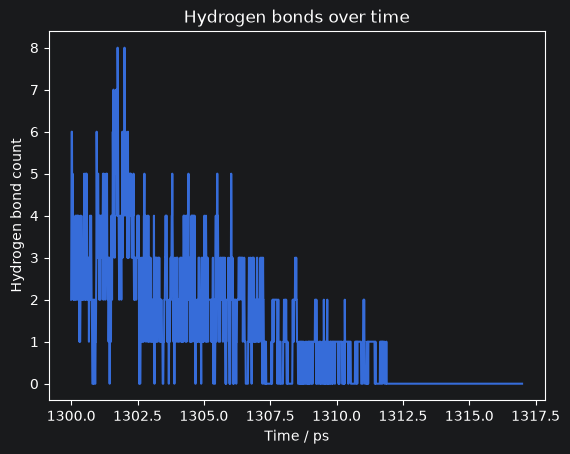

In [14]:
import matplotlib.pyplot as plt

plt.plot(T, COUNT)
plt.xlabel("Time / ps")
plt.ylabel("Hydrogen bond count")
plt.title("Hydrogen bonds over time")
plt.show()

### NanoVer computed energies

NanoVer computes potential and kinetic energy every frame, which is included in the `data` portion of MDAnalysis trajectory timesteps:

In [9]:
from nanover.mdanalysis import universes_from_recording

nanotube = universes_from_recording("../systems/recordings/nanotube-methane-01.nanover.zip")[0]
nanotube.trajectory

<NanoverReaderBase ../systems/recordings/nanotube-methane-01.nanover.zip with 326 frames of 65 atoms>

In [10]:
T = [ts.time for ts in nanotube.trajectory]
PE = [ts.data["energy.potential"] for ts in nanotube.trajectory]
KE = [ts.data["energy.kinetic"] for ts in nanotube.trajectory]

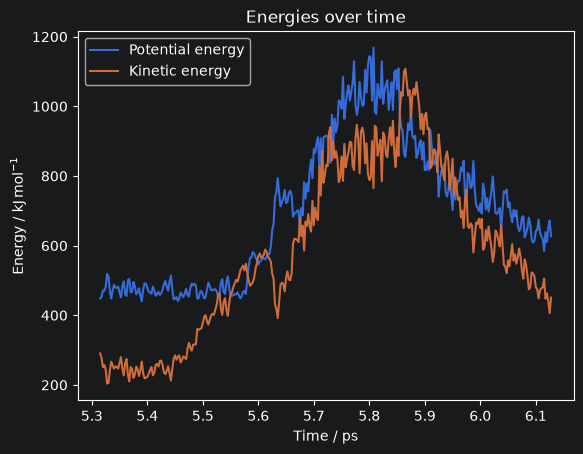

In [11]:
import matplotlib.pyplot as plt

plt.plot(T, PE, label='Potential energy')
plt.plot(T, KE, label='Kinetic energy')
plt.legend()
plt.xlabel("Time / ps")
plt.ylabel(r"Energy / $\mathrm{kJ \, mol}^{-1}$")
plt.title("Energies over time")
plt.show()